# Exploratory Data Analysis (EDA): COVID-19 Impact on Graduate Outcomes
**Research Question:** What was the effect of graduating during the COVID-19 economic downturn on starting salaries and full-time employment rates (FTE) of fresh Australian undergraduates in 2020 compared to the pre-pandemic cohort of 2018?

## Executive Summary
This report analyses outcomes for 21 study areas using 2018 (pre-pandemic) and 2020 (pandemic) Australian graduate survey data.

**Key findings:**
1. **Universal employment decline:** All 21 study areas recorded a fall in full-time employment rates in 2020 (maximum FTE change: −0.1 pp). No field was immune.
2. **Inflation erodes nominal gains:** After applying a 2.7 % CPI adjustment (2018 → 2020), the mean real salary change fell to **+$1,377** (vs. the nominal **+$3,014**). Two fields — Dentistry and Tourism — experienced negative real salary change.
3. **Sectoral divergence:** Technology and engineering graduates were most resilient; physically-dependent professions (Architecture, Medicine, Tourism) suffered the steepest employment declines (up to −10 pp).
4. **Weak salary–employment link:** The correlation between real salary change and FTE change is weak (r ≈ 0.25), consistent with downward wage rigidity, in which salaries did not fall proportionally to job losses.
 > **How to run:** Execute cells top-to-bottom from a clean kernel. The notebook expects `data/clean/final_pandemic_research_data.csv` relative to the repository root.

## Data Dictionary 

| Column | Description | Units |
|--------|-------------|-------|
| `Study_Area` | Field of study (unit of analysis; n = 21 after filtering) |
| `FTE_18` | Full-time employment rate for 2018 graduates | % |
| `FTE_20` | Full-time employment rate for 2020 graduates | % |
| `FTE_Diff` | `FTE_20 − FTE_18` (pandemic employment change) | Percentage points (pp) |
| `Salary_18` | Median starting salary for 2018 graduates (nominal) | AUD ($) |
| `Salary_20` | Median starting salary for 2020 graduates (nominal) | AUD ($) |
| `Salary_Diff` | `Salary_20 − Salary_18` (nominal change, retained for reference) | AUD ($) |
| `Salary_18_Adj` | `Salary_18` inflated to 2020 dollars using CPI multiplier (1.027) | AUD ($) |
| `Real_Salary_Diff` | `Salary_20 − Salary_18_Adj` (inflation-adjusted change) | AUD ($) |

**CPI note:** The multiplier of 1.027 reflects the approximate cumulative CPI change from 2018 to 2020 (ABS Consumer Price Index, All Groups, Australia). `Real_Salary_Diff` is the **primary salary metric** used throughout this report.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Constants ──────────────────────────────────────────────────────────────
# CPI multiplier: approximate cumulative inflation 2018–2020 (ABS CPI All Groups)
CPI_MULTIPLIER = 1.027

# Colour palette (used consistently across all exhibits)
COLOR_POS = '#2d6a4f'  # green – resilient / positive outcome
COLOR_NEG = '#9b2226'  # red   – hard-hit / negative outcome

# Filter pattern for summary rows
FILTER_PATTERN = 'All|Standard deviation'

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid')

# ── Robust data path ───────────────────────────────────────────────────────
# Works whether the notebook is run from the repo root or from code/
_cwd = Path.cwd()
_candidates = [
    _cwd / 'data' / 'clean' / 'final_pandemic_research_data.csv',
    _cwd / '..' / 'data' / 'clean' / 'final_pandemic_research_data.csv',
]
DATA_PATH = next((p.resolve() for p in _candidates if p.resolve().exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find 'data/clean/final_pandemic_research_data.csv'.\n"
        "Run this notebook from the repo root OR from the code/ subdirectory."
    )

# ── Load & filter data ─────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
n_raw = len(df_raw)

df_analysis = df_raw[~df_raw['Study_Area'].str.contains(FILTER_PATTERN, na=False)].copy()
n_clean = len(df_analysis)

print(f'Rows before filtering summary rows : {n_raw}')
print(f'Rows after  filtering summary rows : {n_clean}')

# ── Numeric conversion ─────────────────────────────────────────────────────
def safe_numeric(series):
    """Strip % and , then coerce to numeric; returns NaN for non-parseable values."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace('%', '', regex=False)
              .str.replace(',', '', regex=False),
        errors='coerce'
    )

cols_to_fix = ['FTE_Diff', 'Salary_Diff', 'FTE_18', 'FTE_20', 'Salary_18', 'Salary_20']
for col in cols_to_fix:
    df_analysis[col] = safe_numeric(df_analysis[col])

# Report any NaN values introduced by coercion
na_counts = df_analysis[cols_to_fix].isna().sum()
if na_counts.any():
    print('\nNaN values introduced by numeric coercion:')
    print(na_counts[na_counts > 0])
else:
    print('\nNo NaN values introduced by numeric coercion.')

# ── Inflation adjustment ───────────────────────────────────────────────────
df_analysis['Salary_18_Adj'] = df_analysis['Salary_18'] * CPI_MULTIPLIER
df_analysis['Real_Salary_Diff'] = df_analysis['Salary_20'] - df_analysis['Salary_18_Adj']

# ── Sanity checks ──────────────────────────────────────────────────────────
n_areas = df_analysis['Study_Area'].nunique()
assert n_areas == 21, f'Expected 21 study areas, found {n_areas}'
assert not df_analysis['Study_Area'].str.contains(FILTER_PATTERN, na=False).any(), \
    'Summary rows still present after filtering'

print(f'\nStudy areas confirmed : {n_areas} (expected 21)')
print('Inflation adjustment applied — primary salary metric: Real_Salary_Diff')

Rows before filtering summary rows : 23
Rows after  filtering summary rows : 21

No NaN values introduced by numeric coercion.

Study areas confirmed : 21 (expected 21)
Inflation adjustment applied — primary salary metric: Real_Salary_Diff


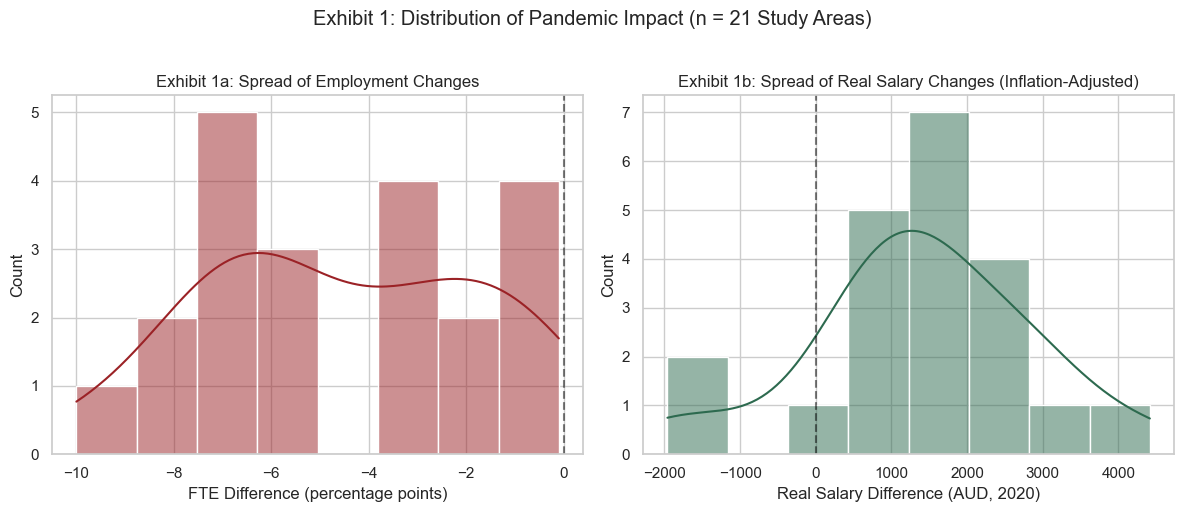

In [2]:
# ── Exhibit 1: Distribution of Pandemic Impact Across Study Areas ───────────
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of Employment Change
plt.subplot(1, 2, 1)
sns.histplot(df_analysis['FTE_Diff'], kde=True, color=COLOR_NEG, bins=8)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Exhibit 1a: Spread of Employment Changes')
plt.xlabel('FTE Difference (percentage points)')
plt.ylabel('Count')

# Plot 2: Histogram of Real Salary Change (Inflation-Adjusted)
plt.subplot(1, 2, 2)
sns.histplot(df_analysis['Real_Salary_Diff'], kde=True, color=COLOR_POS, bins=8)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Exhibit 1b: Spread of Real Salary Changes (Inflation-Adjusted)')
plt.xlabel('Real Salary Difference (AUD, 2020)')
plt.ylabel('Count')

plt.suptitle('Exhibit 1: Distribution of Pandemic Impact (n = 21 Study Areas)', y=1.02)
plt.tight_layout()
plt.show()

### Justification: The Big Picture Spread (Exhibit 1) 
* **What we see:** FTE changes are entirely negative (all bars left of zero), confirming a universal employment decline. Real Salary changes are centered just above zero but with several fields dipping below, more so than the nominal picture would suggest. 
* **Why it matters:** Adjusting for 2.7% inflation reveals that nominal salary gains shrank or turned negative in real terms for some fields, in which an effect invisible without the CPI correction. 
* **Link to Research Question:** Both dimensions of the research question (FTE and salary) show a pandemic-period deterioration; the exhibits below disaggregate this by study area.

In [3]:
# ── Summary statistics: primary metrics ────────────────────────────────────
stats = df_analysis[['Real_Salary_Diff', 'FTE_Diff']].describe()
print(stats.to_string())
print()

n_neg_salary = (df_analysis['Real_Salary_Diff'] < 0).sum()
print(f'Study areas with negative real salary change : {n_neg_salary} of {n_clean}')

n_neg_fte = (df_analysis['FTE_Diff'] < 0).sum()
print(f'Study areas with negative FTE change         : {n_neg_fte} of {n_clean}')

       Real_Salary_Diff   FTE_Diff
count         21.000000  21.000000
mean        1376.542857  -4.523810
std         1481.676227   2.840582
min        -1959.900000 -10.000000
25%          709.800000  -6.500000
50%         1353.000000  -5.200000
75%         2623.200000  -2.000000
max         4415.100000  -0.100000

Study areas with negative real salary change : 2 of 21
Study areas with negative FTE change         : 21 of 21


### Justification: Data Characteristics (Real Metrics)
* **What we see:** Across all 21 study area the mean real salary change is **+$1,377** (well below the nominal **+$3,014**)
* **Why it matters:** Using `Real_Salary_Diff` rather than nominal `Salary_Diff` gives a more accurate picture of graduate purchasing power; two fields (Dentistry and Tourism) that showed nominal salary gains actually lost ground in real terms.
* **Cleaning note:** Filtering summary rows ('All', 'Standard deviation') was necessary to ensure these statistics reflect the 21 individual study areas rather than aggregate national totals.

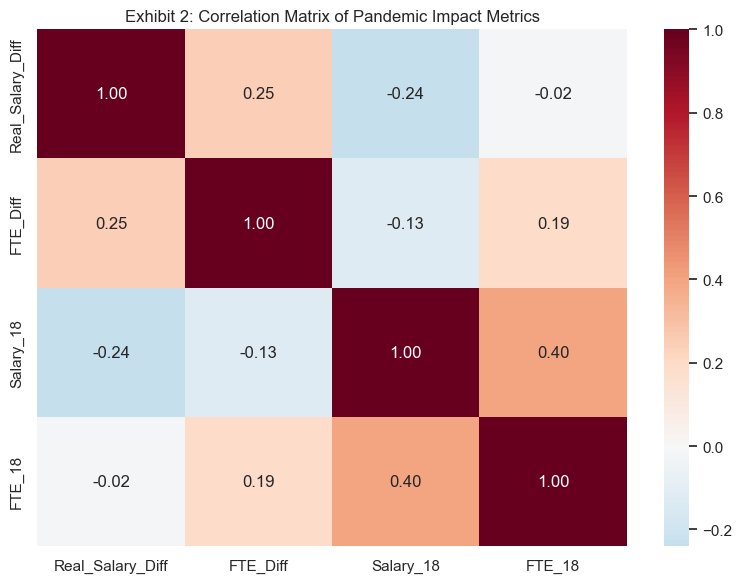

In [4]:
# ── Exhibit 2: Correlation Heatmap ─────────────────────────────────────────
plt.figure(figsize=(8, 6))

corr_cols = ['Real_Salary_Diff', 'FTE_Diff', 'Salary_18', 'FTE_18']
correlation_matrix = df_analysis[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Exhibit 2: Correlation Matrix of Pandemic Impact Metrics')
plt.tight_layout()
plt.show()

### Justification: Exploratory Correlation Analysis (Exhibit 2)
* **What we see:** `Real_Salary_Diff` and `FTE_Diff` shows only a weak positive correlation (r ≈ 0.25), while baseline salary (`Salary_18`) and baseline employment (`FTE_18`) are moderately correlated with each other. 
* **Why it matters:** A weak `Real_Salary_Diff`-`FTE_Diff` correlation indicates that fields which lost more jobs did not necessarily experience proportionally larger real salary declines, in which consistent with **downward wage rigidity**. Entry-level professional salaries in Australia appear to resist cuts even under labour-demand shocks. 
* **Link to Research Question:** The pandemic impacted job quantity (FTE) far more consistently than job price (real salary). Future modelling should include industry-specific factors (e.g., essential-service status, remote-work feasibility) as additional predictors beyond the general FTE trend.

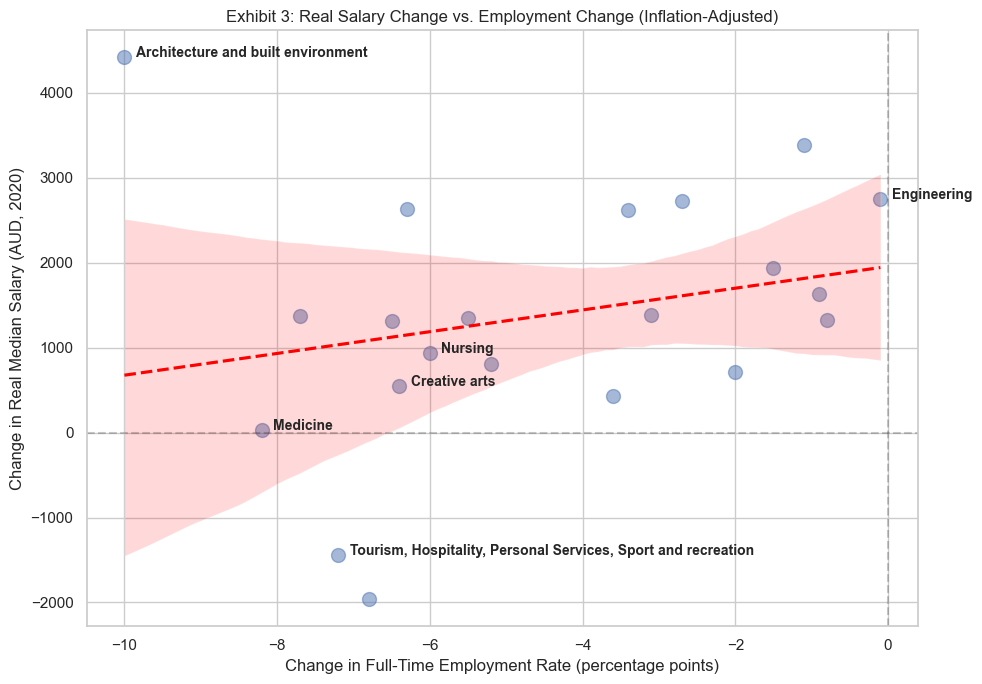

In [5]:
# ── Exhibit 3: Real Salary Change vs. Employment Change ─────────────────────
plt.figure(figsize=(10, 7))

sns.regplot(data=df_analysis, x='FTE_Diff', y='Real_Salary_Diff',
            scatter_kws={'s': 100, 'alpha': 0.5},
            line_kws={'color': 'red', 'linestyle': '--'})

plt.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.axvline(0, color='black', linestyle='--', alpha=0.2)

# Annotate selected sectors
targets = ['Engineering', 'Nursing', 'Tourism', 'Medicine', 'Creative arts', 'Architecture']
for i in range(df_analysis.shape[0]):
    area = df_analysis['Study_Area'].iloc[i]
    if any(t in area for t in targets):
        plt.text(df_analysis['FTE_Diff'].iloc[i] + 0.15,
                 df_analysis['Real_Salary_Diff'].iloc[i],
                 area, fontsize=10, fontweight='bold')

plt.title('Exhibit 3: Real Salary Change vs. Employment Change (Inflation-Adjusted)')
plt.xlabel('Change in Full-Time Employment Rate (percentage points)')
plt.ylabel('Change in Real Median Salary (AUD, 2020)')
plt.tight_layout()
plt.show()

### Justification: Targeted Industry Analysis (Exhibit 3) 
* **What we see:** The regression line has a positive slope: fields with steeper FTE declines tend to show lower (or negative) real salary growth. Tourism sits in the bottom-left quadrant, in which the worst outcome on both dimensions. Engineering sits near the top-right, relatively shielded on both metrics. 
* **Why it matters:** The scatter highlights heterogeneity. Medicine and Architecture suffered large FTE drops but avoided salary collapse, pointing to wage stickiness in high-prestige professions. Nursing shows a small FTE loss but also modest real salary growth, consistent with essential-but-budget-constrained roles.
* **Link to Research Question:** The sectoral relationship is real but weak, suggesting that industry-specific characteristics such as physical-presence requirements, essential-service status, and professional salary floors mediate the pandemic's effect on graduate outcomes. Note n = 21; findings are exploratory.

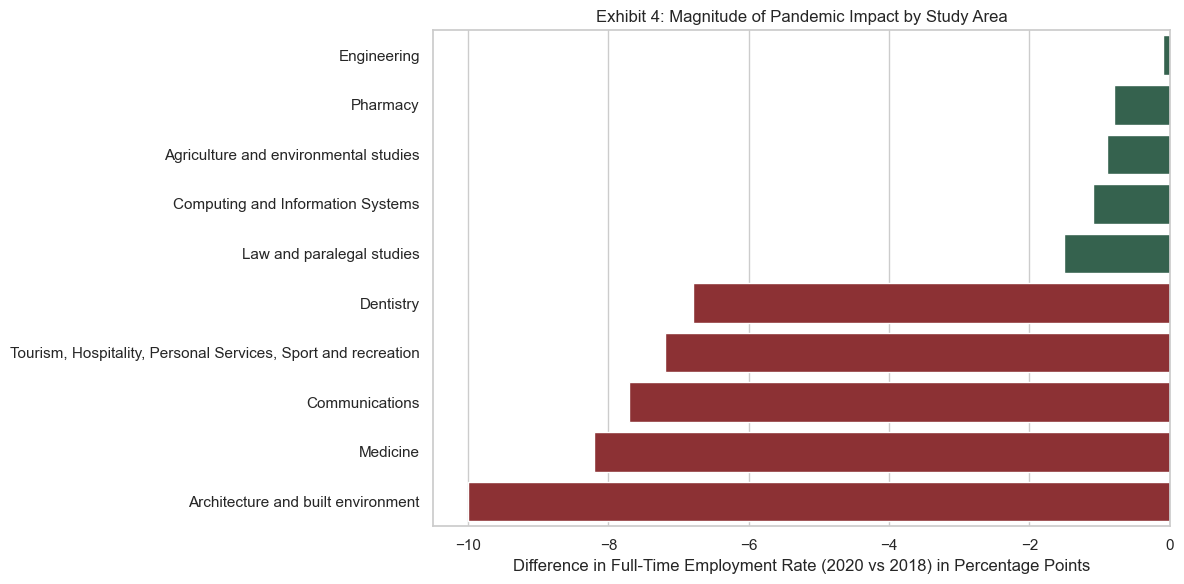

In [6]:
# ── Exhibit 4: Top 5 Resilient & Bottom 5 Most-Affected Study Areas ─────────
df_sorted = df_analysis.sort_values('FTE_Diff', ascending=False)
winners_losers = pd.concat([df_sorted.head(5), df_sorted.tail(5)])

# Deterministic bar order and colour mapping
order = winners_losers['Study_Area'].tolist()
colors = [COLOR_POS] * 5 + [COLOR_NEG] * 5
color_map = dict(zip(order, colors))

plt.figure(figsize=(12, 6))
sns.barplot(data=winners_losers, x='FTE_Diff', y='Study_Area',
            order=order, palette=color_map, hue='Study_Area', legend=False)
plt.title('Exhibit 4: Magnitude of Pandemic Impact by Study Area')
plt.xlabel('Difference in Full-Time Employment Rate (2020 vs 2018) in Percentage Points')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Justification: Who was hit hardest by COVID-19? (Exhibit 4)
* **What we see:** Engineering and Computing (green) recorded the smallest FTE declines (≈ -1 percentage points), while Architecture and Medicine (red) lost up to -10 percentage points of full-time employment.
* **Why it matters:** The contrast between digital/knowledge-work fields and physical-presence fields is stark. Remote-work feasibility was a key moderating factor during lockdowns. 
* **Link to Research Question:** The pandemic did not affect all graduates equally, in which it functioned as a 'sectoral lectory'. Graduates in computer-based fields were largely insulated, while those in sectors requiring physical presence or elective/non-essential services faced a much harder labour market in 2020.  


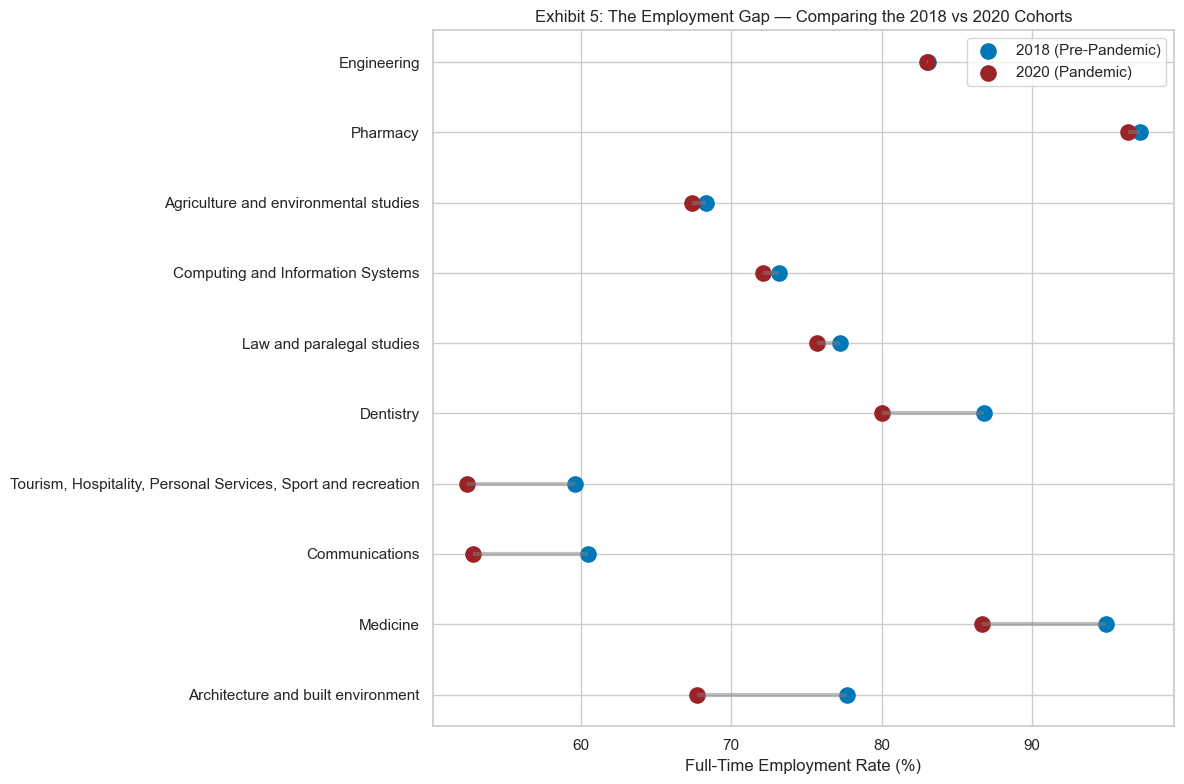

In [7]:
# ── Exhibit 5: Employment Gap — 2018 vs 2020 Cohorts ───────────────────────
df_sorted = df_analysis.sort_values('FTE_Diff', ascending=True)
top_bottom = pd.concat([df_sorted.head(5), df_sorted.tail(5)])

plt.figure(figsize=(12, 8))
plt.hlines(y=top_bottom['Study_Area'],
           xmin=top_bottom['FTE_20'], xmax=top_bottom['FTE_18'],
           color='grey', alpha=0.5, linewidth=3)

plt.scatter(top_bottom['FTE_18'], top_bottom['Study_Area'],
            color='#0077b6', s=120, label='2018 (Pre-Pandemic)')
plt.scatter(top_bottom['FTE_20'], top_bottom['Study_Area'],
            color=COLOR_NEG, s=120, label='2020 (Pandemic)')

plt.title('Exhibit 5: The Employment Gap — Comparing the 2018 vs 2020 Cohorts')
plt.xlabel('Full-Time Employment Rate (%)')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

### Justification: The Story of the Employment Gap (Exhibit 5)
* **What we see:** The dumbbell plot shows the before and after shift in full-time employment rates. Engineering has almost no gap (pandemic-immune), while Medicine and Architecture have the widest gaps. 
* **Why it matters:** Line length directly quantifies the pandemic penalty for each field, in which a longer line represents a larger cohort-level opportunity loss for the 2020 class versus 2018.
* **Link to Research Question:** The downturn was not a rising tide that lowers all boats equally, it was a selective crisis that widened inequality between fields of study, disproportionately affecting those dependent on physical presence or elective/non-essential services. 

## Project Limitations & Conclusion

### Limitations
1. **Short Timeframe:** This study only compares 2018 to 2020. It does not show 2021 or 2022 (Recovery trajectories), so we do not know yet how fast these groups bounced back after the pandemic. 
2. **Aggregated data:** We used median numbers for entire fields. This means we cannot see the difference between a student at a top city univeristy versus a student in a small town, even if they studied the same thing.  
3. **Observational design:** The 2018 and 2020 cohorts are separate cross-sections, not longitudinal tracking of the same individuals Differences may partly reflect cohort composition rather than purely pandemic effects.
4. **Small n:** With 21 study areas, all statistical relationships should be interpreted as exploratory rather than confirmatory. 

### Conclusion
The 2020 economic downturn created a clear **Sectoral Lottery**. Graduates in technology and essential engineering roles were shielded from both job losses and inflation-adjusted salary hits. However, sectors like Medicine and Architecture in which rely on physical presence and elective services, suffered massive employment gaps. By accounting for inflation, we can see that the pandemic's real ecnomic hit was more severe than nominal figures suggested, particularly for sectors already struggling with low employment stability. The weak correlation between real salary change and FTE change is consistent with downward wage rigidity, suggesting that salary floors held even as hiring volumes fell. 